**Ruiqi Liu**  
**CS6220**  
**Assignment 6**  
**2/20/2025**  

---



### Part 1: Exploratory Data Analysis

**Objective:**  
Subset the dataset to include data from 1962 to 2002. Understand the distribution of the target variable (Runs Scored) and the relationships between the target and predictor variables.

**Steps:**
1. Load the dataset.
2. Filter the dataset for years between 1962 and 2002.
3. Generate summary statistics.
4. Plot the distribution of Runs Scored.
5. Plot scatter plots and a correlation heatmap for key predictor variables.

Dataset subset (1962-2002):
    Team League  Year   RS   RA    W    OBP    SLG     BA  Playoffs  \
300  ANA     AL  2002  851  644   99  0.341  0.433  0.282         1   
301  ARI     NL  2002  819  674   98  0.346  0.423  0.267         1   
302  ATL     NL  2002  708  565  101  0.331  0.409  0.260         1   
303  BAL     AL  2002  667  773   67  0.309  0.403  0.246         0   
304  BOS     AL  2002  859  665   93  0.345  0.444  0.277         0   

     RankSeason  RankPlayoffs    G   OOBP   OSLG  
300         3.0           1.0  162  0.314  0.392  
301         4.0           4.0  162  0.305  0.397  
302         2.0           4.0  161  0.313  0.364  
303         NaN           NaN  162  0.336  0.435  
304         NaN           NaN  162  0.308  0.385  

Summary Statistics:
              Year           RS           RA           W         OBP  \
count   932.000000   932.000000   932.000000  932.000000  932.000000   
mean   1982.989270   705.197425   705.197425   80.879828    0.325153   
st

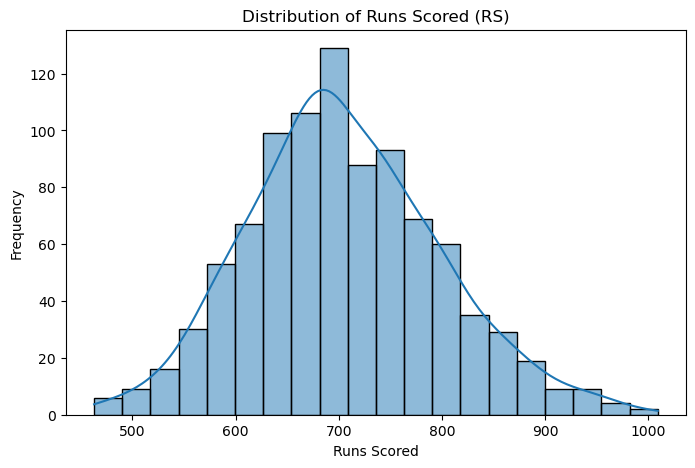

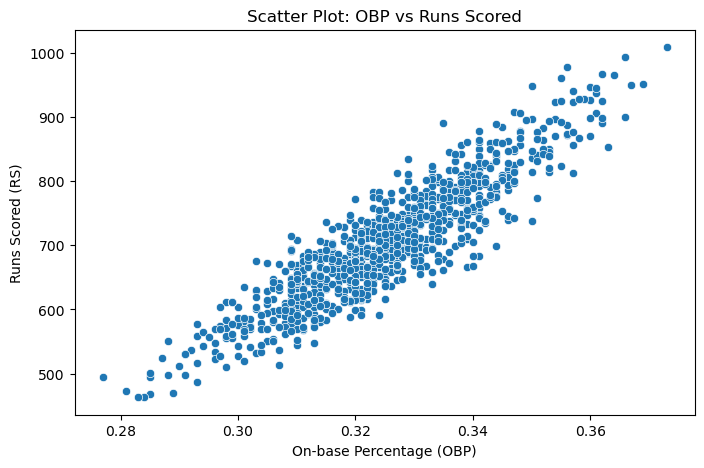

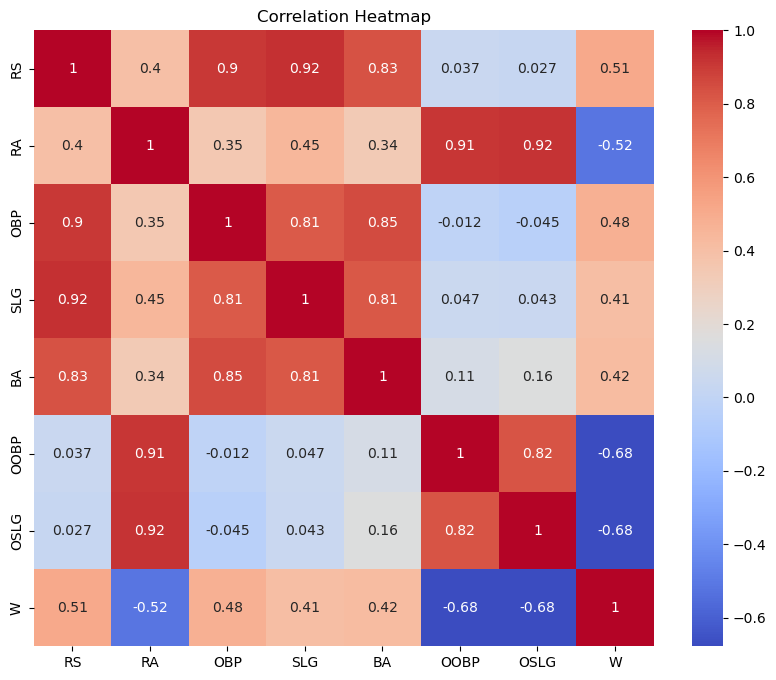

In [10]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('baseball.csv')

# Ensure the 'Year' column is numeric
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Subset the dataset for years between 1962 and 2002
df_subset = df[(df['Year'] >= 1962) & (df['Year'] <= 2002)]

# Display first few rows of the subset
print("Dataset subset (1962-2002):")
print(df_subset.head())

# Generate summary statistics for numerical columns
print("\nSummary Statistics:")
print(df_subset.describe())

# Plot the distribution of Runs Scored (RS)
plt.figure(figsize=(8, 5))
sns.histplot(df_subset['RS'], kde=True, bins=20)
plt.title("Distribution of Runs Scored (RS)")
plt.xlabel("Runs Scored")
plt.ylabel("Frequency")
plt.show()

# Example scatter plot: OBP vs Runs Scored
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_subset, x='OBP', y='RS')
plt.title("Scatter Plot: OBP vs Runs Scored")
plt.xlabel("On-base Percentage (OBP)")
plt.ylabel("Runs Scored (RS)")
plt.show()

# Plot a correlation heatmap of key variables
plt.figure(figsize=(10, 8))
# List of columns to include in the correlation analysis
corr_columns = ['RS', 'RA', 'OBP', 'SLG', 'BA', 'OOBP', 'OSLG', 'W']
corr_matrix = df_subset[corr_columns].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


### Part 2: Wins to Playoffs

**Objective:**  
Verify the claim that teams with at least 95 wins almost always make the playoffs.

**Steps:**
1. Create a scatter plot of Wins versus Team.
2. Color the points based on whether the team made the playoffs or not.


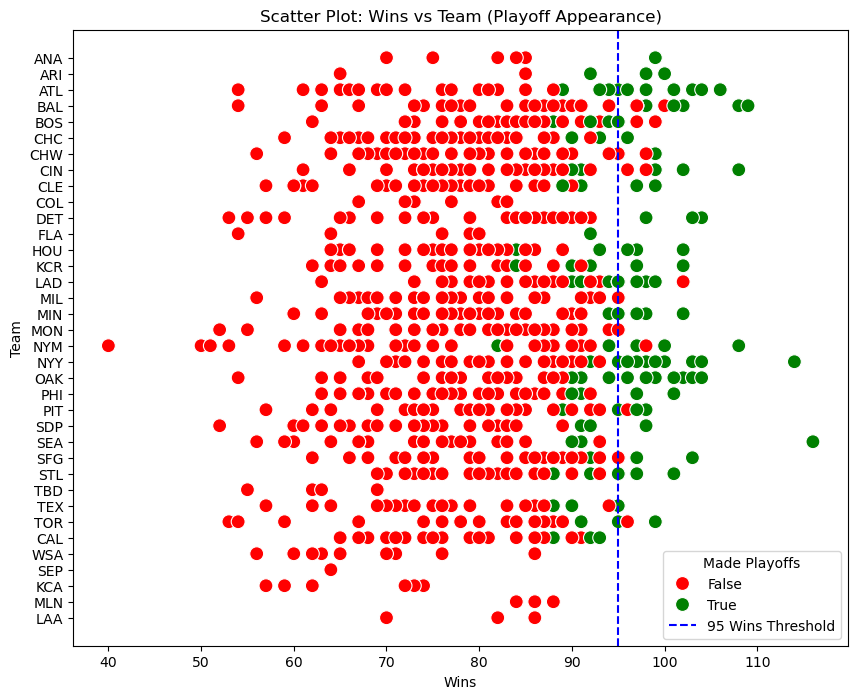

In [13]:
# Ensure that the 'Playoffs' column is boolean
df_subset.loc[:, 'Playoffs'] = df_subset['Playoffs'].astype(bool)

# Create a scatter plot of Wins (x-axis) vs Team (y-axis) colored by playoff appearance
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_subset, x='W', y='Team', hue='Playoffs', 
                palette={True: 'green', False: 'red'}, s=100)
# Draw a vertical line at the 95 wins threshold
plt.axvline(95, color='blue', linestyle='--', label='95 Wins Threshold')
plt.title("Scatter Plot: Wins vs Team (Playoff Appearance)")
plt.xlabel("Wins")
plt.ylabel("Team")
plt.legend(title="Made Playoffs")
plt.show()


### Part 3: Runs to Score

**Objective:**  
Determine how many runs a team needs to score to make the playoffs by calculating the Run Difference (RD = Runs Scored - Runs Allowed) and analyzing its relationship with Wins.

**Steps:**
1. Calculate the Run Difference (RD) for each team.
2. Create a scatter plot of Run Difference (x-axis) versus Wins (y-axis), colored by playoff appearance.
3. Observe and comment on the relationship between Run Difference and Wins.


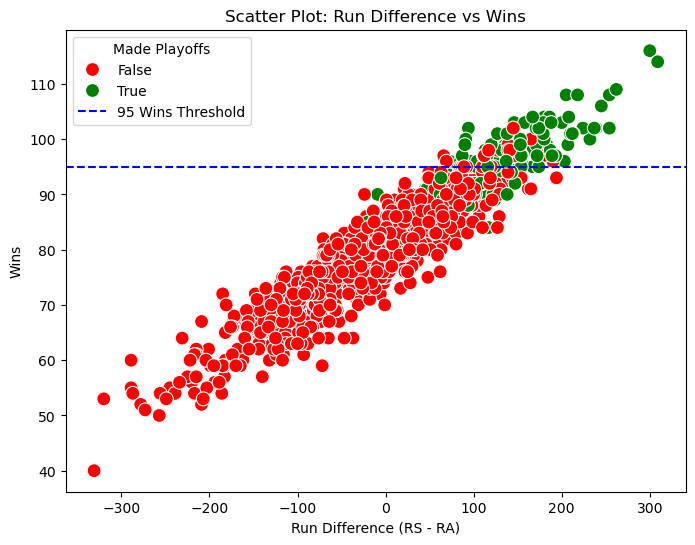

In [17]:
# Calculate Run Difference (RD)
df_subset.loc[:, 'RD'] = df_subset['RS'] - df_subset['RA']

# Create a scatter plot of Run Difference vs Wins colored by playoff appearance
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_subset, x='RD', y='W', hue='Playoffs', 
                palette={True: 'green', False: 'red'}, s=100)
plt.title("Scatter Plot: Run Difference vs Wins")
plt.xlabel("Run Difference (RS - RA)")
plt.ylabel("Wins")
plt.axhline(95, color='blue', linestyle='--', label='95 Wins Threshold')
plt.legend(title="Made Playoffs")
plt.show()


### Part 4: Wins Regression

**Objective:**  
Develop a linear regression model to predict Wins based on Run Difference (RD), evaluate its performance, and determine the RD needed to achieve 95 wins (playoff threshold).

**Steps:**
1. Split the dataset into training (80%) and testing (20%) sets.
2. Fit a linear regression model using Run Difference as the predictor and Wins as the target.
3. Evaluate the model using Mean Squared Error (MSE) and R-squared on the test set.
4. Display the regression equation (coefficients and intercept).
5. Calculate the required Run Difference to achieve 95 wins.


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define the predictor and target for Wins regression
X = df_subset[['RD']]   # Predictor: Run Difference
y = df_subset['W']   # Target: Wins

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and fit the linear regression model
wins_model = LinearRegression()
wins_model.fit(X_train, y_train)

# Predict wins on the testing set
y_pred = wins_model.predict(X_test)

# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Wins Regression Model Performance:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared: {r2:.2f}")

# Retrieve the regression model parameters
intercept = wins_model.intercept_
coefficient = wins_model.coef_[0]
print("\nRegression Equation: Wins = {:.2f} + {:.2f} * RD".format(intercept, coefficient))

# Calculate the required Run Difference to achieve 95 wins
rd_required = (95 - intercept) / coefficient
print(f"\nRequired Run Difference (RD) to achieve 95 wins: {rd_required:.2f}")


Wins Regression Model Performance:
Mean Squared Error (MSE): 13.91
R-squared: 0.88

Regression Equation: Wins = 80.92 + 0.11 * RD

Required Run Difference (RD) to achieve 95 wins: 132.50


### Part 5: Runs Scored Regression

**Objective:**  
Build a linear regression model to predict Runs Scored (RS) based on On-base Percentage (OBP) and Slugging Percentage (SLG). Provide the regression equation including coefficients and intercept.

**Steps:**
1. Define OBP and SLG as predictors and RS as the target.
2. Fit a linear regression model.
3. Display the model's coefficients, intercept, and regression equation.


In [19]:
# Define predictors and target for Runs Scored regression
X_rs = df_subset[['OBP', 'SLG']]
y_rs = df_subset['RS']

# Split the data into training and testing sets
X_train_rs, X_test_rs, y_train_rs, y_test_rs = train_test_split(X_rs, y_rs, test_size=0.2, random_state=42)

# Create and fit the Runs Scored regression model
rs_model = LinearRegression()
rs_model.fit(X_train_rs, y_train_rs)

# Retrieve model coefficients and intercept
intercept_rs = rs_model.intercept_
coef_obp, coef_slg = rs_model.coef_

print("Runs Scored Regression Model:")
print(f"Intercept: {intercept_rs:.2f}")
print(f"Coefficient for OBP: {coef_obp:.2f}")
print(f"Coefficient for SLG: {coef_slg:.2f}")

print("\nRegression Equation: RS = {:.2f} + ({:.2f} * OBP) + ({:.2f} * SLG)".format(intercept_rs, coef_obp, coef_slg))


Runs Scored Regression Model:
Intercept: -811.13
Coefficient for OBP: 2771.17
Coefficient for SLG: 1572.55

Regression Equation: RS = -811.13 + (2771.17 * OBP) + (1572.55 * SLG)


### Part 6: Runs Allowed Regression

**Objective:**  
Develop a linear regression model to predict Runs Allowed (RA) based on Opponent’s On-base Percentage (OOBP) and Opponent’s Slugging Percentage (OSLG). Provide the regression equation with coefficients and intercept.

**Steps:**
1. Define OOBP and OSLG as predictors and RA as the target.
2. Fit a linear regression model.
3. Display the regression equation.


In [22]:
# Define predictors and target for Runs Allowed regression
df_subset = df_subset.dropna(subset=['OOBP', 'OSLG'])
X_ra = df_subset[['OOBP', 'OSLG']]
y_ra = df_subset['RA']

# Split the data into training and testing sets
X_train_ra, X_test_ra, y_train_ra, y_test_ra = train_test_split(X_ra, y_ra, test_size=0.2, random_state=42)

# Create and fit the Runs Allowed regression model
ra_model = LinearRegression()
ra_model.fit(X_train_ra, y_train_ra)

# Retrieve model coefficients and intercept
intercept_ra = ra_model.intercept_
coef_oobp, coef_oslg = ra_model.coef_

print("Runs Allowed Regression Model:")
print(f"Intercept: {intercept_ra:.2f}")
print(f"Coefficient for OOBP: {coef_oobp:.2f}")
print(f"Coefficient for OSLG: {coef_oslg:.2f}")

print("\nRegression Equation: RA = {:.2f} + ({:.2f} * OOBP) + ({:.2f} * OSLG)".format(intercept_ra, coef_oobp, coef_oslg))


Runs Allowed Regression Model:
Intercept: -866.76
Coefficient for OOBP: 2731.22
Coefficient for OSLG: 1717.55

Regression Equation: RA = -866.76 + (2731.22 * OOBP) + (1717.55 * OSLG)


### Part 7: Wins Prediction

**Objective:**  
Predict the number of wins for the Oakland A's in 2002 using the regression models developed in Parts 4, 5, and 6, given the following previous-year statistics:  
- OBP: 0.339  
- SLG: 0.432  
- OOBP: 0.315  
- OSLG: 0.384  

**Steps:**
1. Use the Runs Scored model (Part 5) to predict RS from OBP and SLG.
2. Use the Runs Allowed model (Part 6) to predict RA from OOBP and OSLG.
3. Calculate the predicted Run Difference (RD = predicted RS – predicted RA).
4. Use the Wins regression model (Part 4) to predict Wins using the predicted RD.
5. Compare the predicted wins with the actual wins and provide insights.


In [27]:
# Define the input statistics for the Oakland A's
input_stats = {
    'OBP': 0.339,
    'SLG': 0.432,
    'OOBP': 0.315,
    'OSLG': 0.384
}

# Prepare DataFrames for prediction for Runs Scored and Runs Allowed
input_df_rs = pd.DataFrame({
    'OBP': [input_stats['OBP']],
    'SLG': [input_stats['SLG']]
})

input_df_ra = pd.DataFrame({
    'OOBP': [input_stats['OOBP']],
    'OSLG': [input_stats['OSLG']]
})

# Predict Runs Scored using the Runs Scored model
predicted_RS = rs_model.predict(input_df_rs)[0]
print(f"Predicted Runs Scored (RS): {predicted_RS:.2f}")

# Predict Runs Allowed using the Runs Allowed model
predicted_RA = ra_model.predict(input_df_ra)[0]
print(f"Predicted Runs Allowed (RA): {predicted_RA:.2f}")

# Calculate the predicted Run Difference (RD)
predicted_RD = predicted_RS - predicted_RA
print(f"Predicted Run Difference (RD): {predicted_RD:.2f}")

# Predict Wins using the Wins regression model (from Part 4)
predicted_Wins = wins_model.predict(pd.DataFrame({'RD': [predicted_RD]}))[0]
print(f"\nPredicted Wins for the Oakland A's in 2002: {predicted_Wins:.2f}")

# For comparison, assume the actual wins are available (e.g., 103 wins in 2002)
actual_wins = 103  # Update if a different actual value is known
print(f"Actual Wins in 2002: {actual_wins}")


Predicted Runs Scored (RS): 807.64
Predicted Runs Allowed (RA): 653.11
Predicted Run Difference (RD): 154.52

Predicted Wins for the Oakland A's in 2002: 97.34
Actual Wins in 2002: 103
